# Max-basis arm B (s=1.41) on NSTX_MTM n300, MTM-only (Fusion_PhD-bhx7.12)

User, 2026-10-02: "This needs to be an MTM database, we should be using the rules I established to remove anything that isn't an MTM." (`docs/mode_filtering.md`, "Populations".)

**Population.** NSTX_MTM GS2 cases with $\gamma_{GS2} > 10^{-3}$ whose GS2 dominant mode `general_analysis.mode_classification.classify` labels MTM ($T > 0.15$ and $\omega < 0$; `Fusion_PhD-lqwx`, GA master `77e04d9`). Everything else (KBM, mixed, GS2-stable) is removed and the count is printed.

**Scoring the code (user, 2026-10-02).** GFTM is never filtered. Its dominant mode (mode 0: IBRANCH=-1 sorts modes by $\gamma$, asserted on load) is scored whatever its type. *Capture* = that mode is an MTM by $T>0.15$ and $\omega<0$. A dominant mode that is not an MTM is a capture failure whose growth-rate error still counts in medlog / medAE. No unstable mode, or no deck, is a MISS ($+\infty$), kept.

GFTM's $T$ is the pyro formula $|\int A_\parallel d\theta| / \int |A_\parallel| d\theta$ on the stored theta-resolved `apar` of the dominant mode (unit $dl$ weight, Simpson). For the GyroRun max-basis arm the stored `tearing_parameter` is read instead (identical to the recomputed value, max |diff| 0, Fusion_PhD-0b1e).

Scored beside the existing n300 arms from `mtm_only_rescore`. Everything is read from each leaf's `pyroscan.nc` through `PyroHypercube(pyroscan_json=..., load_base_pyro=True)` and `load_gk_output(netcdf_file=...)`; no run directory is opened.

## Imports and settings

In [1]:
from pathlib import Path
import os
from dotenv import load_dotenv
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from scipy.integrate import simpson
from pyrokinetics import PyroHypercube
from general_analysis import mode_classification as mc
from general_analysis.mode_classification import T_TEAR

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "notebooks").is_dir())
plt.style.use(ROOT / "src/general_analysis/paper.mplstyle")
plt.rcParams.update({"axes.titlesize": 16, "axes.labelsize": 16, "xtick.labelsize": 14, "ytick.labelsize": 14, "legend.fontsize": 12})
load_dotenv(ROOT / "local.env", override=True)

analysis_name = "mtm_maxbasis_n300"
data_root = Path(os.environ["GK_DATA_ROOT"]).expanduser()
base = data_root / "GFTM/Runs/LATIN_HYPERCUBE/NSTX_MTM"
gs2_base = data_root / "GS2/Runs/LATIN_HYPERCUBE/NSTX_MTM"

# label -> (leaf, folder with the cube, file kind)
arms_all = {
    "A maxbasis s=1":    ("extent_maxbasis_s100", "", "gyrorun"),
    "B maxbasis s=1.41": ("extent_maxbasis_s141", "", "gyrorun"),
    "m11_new":           ("m11_new", "pyro_cube", "cube"),
    "m9_new":            ("m9_new", "pyro_cube", "cube"),
    "rule s=1":          ("extent_rule_tf035", "pyro_cube", "cube"),
    "rule s=1.41":       ("extent_rule_tf035_s141", "pyro_cube", "cube"),
    "fw174":             ("gftm_fw174", "pyro_cube", "cube"),
}
# n300 only (Fusion_PhD-bhx7.12). Arm B is the new leaf; arm A was never built on n300.
arms_all.pop("A maxbasis s=1")
draws = {"n300": ("beta_q_shat_ky_n300", list(arms_all))}
gs2_unstable = 1e-3
n_boot, seed = 2000, 0

## Load and score

Per draw: the GS2 cube (`pyro_cube_avg`, tail-averaged $\gamma$ as in every earlier analysis), the GS2 classifier label per GS2-unstable case (`mc.indicators(scan, ds)` on the same tail-averaged cube, no run directory; `lqwx` used each run's final time), and every GFTM arm's dominant-mode $\gamma$, $\omega$, $T$ (pyro's `FieldLine` with each sample's own $dl$ stored as `tearing_parameter` on GyroRun leaves, computed with `mc.tearing_parity` on legacy cubes; the earlier $dl=1$ value is kept as `T_dl1` and the number of capture labels that change is printed).

In [2]:
def tearing(ds):
    """(sample, mode) |int A dtheta| / int |A| dtheta, as pyro's compute_linear_tearing_parameter with dl = 1."""
    apar = np.asarray(ds.eigenfunctions.sel(field="apar").transpose("sample", "mode", "theta").values)
    theta = np.asarray(ds.theta.values, float)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.abs(simpson(apar, x=theta, axis=-1)) / simpson(np.abs(apar), x=theta, axis=-1)

results = {}
for dname, (draw, arms) in draws.items():
    gs2_dir = gs2_base / draw / "pyro_cube_avg"
    gs2_scan = PyroHypercube(pyroscan_json=gs2_dir / "pyroscan.json", load_base_pyro=True)
    mc.attach_legacy_funcs(gs2_scan)   # this json predates parameter_func serialisation: re-attach beta -> beta_prime
    gs2_scan.load_gk_output(netcdf_file=gs2_dir / "cube.nc")
    gs2 = gs2_scan.gk_output.data
    names = [str(name) for name in gs2.sample_name.values]
    gamma_gs2 = np.asarray(gs2.growth_rate.values, float).reshape(len(names), -1)[:, 0]
    unstable = gamma_gs2 > gs2_unstable
    label = np.where(unstable, mc.classify(mc.indicators(gs2_scan, gs2)), "").astype(object)
    draw_result = dict(names=names, gamma_gs2=gamma_gs2, unstable=unstable, label=label, arm={})
    for arm in arms:
        leaf, sub, kind = arms_all[arm]
        cube_dir = base / draw / leaf / sub
        gftm_scan = PyroHypercube(pyroscan_json=cube_dir / "pyroscan.json", load_base_pyro=True)
        gftm_scan.load_gk_output(netcdf_file=cube_dir / ("cube.nc" if kind == "cube" else "pyroscan.nc"))
        gftm = gftm_scan.gk_output.data
        # IBRANCH=-1: modes come sorted by growth rate, so mode 0 is the dominant mode
        assert (gftm.growth_rate.pint.dequantify().fillna(-np.inf).argmax("mode") == 0).all()
        row = {str(name): i for i, name in enumerate(gftm.sample_name.values)}
        take = np.array([row.get(name, -1) for name in names])
        have, idx = take >= 0, np.maximum(take, 0)
        if "tearing_parameter" in gftm:   # GyroRun leaf: pyro's T stored at save time, each sample's own dl
            tearing_pyro = gftm.tearing_parameter
        else:   # legacy cube: same FieldLine T, computed here per sample
            tearing_pyro = mc.tearing_parity(gftm_scan, gftm, np.flatnonzero(np.isin(np.arange(gftm.sizes["sample"]), take[have])))["T"]
        dominant = lambda values: np.where(have, np.asarray(values, float)[:, 0][idx], np.nan)
        arm_result = dict(have=have,
                          gamma=dominant(gftm.growth_rate.transpose("sample", "mode").values),
                          omega=dominant(gftm.mode_frequency.transpose("sample", "mode").values),
                          T=dominant(tearing_pyro.isel(kx=0, drop=True, missing_dims="ignore").transpose("sample", "mode").values),
                          T_dl1=dominant(tearing(gftm)))   # dl = 1, the cube-only T of earlier versions
        draw_result["arm"][arm] = arm_result
        print(dname, arm, "decks", int(have.sum()))
    results[dname] = draw_result
    unstable_labels = label[unstable]
    print(dname, f"{len(names)} cases, GS2-unstable {unstable.sum()}:", {kind: int((unstable_labels == kind).sum()) for kind in ("MTM", "KBM", "mixed")})

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n300 B maxbasis s=1.41 decks 300


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


...

/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n300 rule s=1.41 decks 297


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


n300 fw174 decks 300
n300 300 cases, GS2-unstable 269: {'MTM': 209, 'KBM': 37, 'mixed': 23}


/pitagora_work/FUPB2_QLTURB/fwatts/GyroRun/.venv/lib/python3.12/site-packages/xarray/core/variable.py:363: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Population and the removed count

In [3]:
for dname, draw_result in results.items():
    n_cases, n_unstable = len(draw_result["names"]), int(draw_result["unstable"].sum())
    unstable_labels = draw_result["label"][draw_result["unstable"]]
    n_mtm = int((unstable_labels == "MTM").sum())
    draw_result["mtm"] = draw_result["unstable"] & (draw_result["label"] == "MTM")
    print(f"{dname}: {n_cases} cases | GS2-stable {n_cases - n_unstable} | KBM {int((unstable_labels == 'KBM').sum())} | mixed {int((unstable_labels == 'mixed').sum())} "
          f"| MTM kept {n_mtm} | removed {n_cases - n_mtm} of {n_cases} ({n_unstable - n_mtm} of {n_unstable} GS2-unstable)")

n300: 300 cases | GS2-stable 31 | KBM 37 | mixed 23 | MTM kept 209 | removed 91 of 300 (60 of 269 GS2-unstable)


## Capture

Capture = $\gamma>0$ and $\omega<0$ and $T>0.15$ on the dominant mode.

In [4]:
for dname, draw_result in results.items():
    for arm, arm_result in draw_result["arm"].items():
        arm_result["mtm_mode"] = arm_result["have"] & (arm_result["gamma"] > 0) & (arm_result["omega"] < 0) & (arm_result["T"] > T_TEAR)
        arm_result["mtm_mode_dl1"] = arm_result["have"] & (arm_result["gamma"] > 0) & (arm_result["omega"] < 0) & (arm_result["T_dl1"] > T_TEAR)
    mtm_population = draw_result["label"] == "MTM"
    for arm, arm_result in draw_result["arm"].items():
        changed = arm_result["mtm_mode"] != arm_result["mtm_mode_dl1"]
        print(f"{dname} {arm}: capture labels that change from dl = 1 to pyro's dl: {int(changed.sum())} of {len(mtm_population)} cases, "
              f"{int((changed & mtm_population).sum())} of {int(mtm_population.sum())} in the MTM-only population")

n300 B maxbasis s=1.41: |T - T_stored| median 0.00e+00, max 0.00e+00; side of 0.15 differs on 0 of 295
n300 B maxbasis s=1.41: capture labels that change from dl = 1 to pyro's dl: 3 of 300 cases, 3 of 209 in the MTM-only population
n300 m11_new: capture labels that change from dl = 1 to pyro's dl: 1 of 300 cases, 1 of 209 in the MTM-only population
n300 m9_new: capture labels that change from dl = 1 to pyro's dl: 2 of 300 cases, 2 of 209 in the MTM-only population
n300 rule s=1: capture labels that change from dl = 1 to pyro's dl: 1 of 300 cases, 0 of 209 in the MTM-only population
n300 rule s=1.41: capture labels that change from dl = 1 to pyro's dl: 2 of 300 cases, 2 of 209 in the MTM-only population
n300 fw174: capture labels that change from dl = 1 to pyro's dl: 0 of 300 cases, 0 of 209 in the MTM-only population


## Score every arm on the MTM-only population

medlog = median $|\log_{10}(\gamma_{GFTM}/\gamma_{GS2})|$, medAE = median $|\gamma_{GFTM}-\gamma_{GS2}|$, dominant mode, misses $+\infty$, capture failures scored on their own $\gamma$. 95% bootstrap intervals; the same resampled cases for every arm.

In [5]:
def score(draw_result, arm, mask):
    arm_result = draw_result["arm"][arm]
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = arm_result["gamma"] / draw_result["gamma_gs2"]
    positive = arm_result["have"] & (arm_result["gamma"] > 0)
    log_error = np.where(positive, np.abs(np.log10(ratio)), np.inf)
    abs_error = np.where(positive, np.abs(arm_result["gamma"] - draw_result["gamma_gs2"]), np.inf)
    captured = arm_result["mtm_mode"]
    return dict(e=log_error[mask], ae=abs_error[mask], cap=captured[mask], miss=~positive[mask])

rng = np.random.default_rng(seed)
def table(draw_result, arms, mask):
    n_cases = int(mask.sum())
    boot_idx = rng.integers(0, n_cases, (n_boot, n_cases))
    out = {}
    for arm in arms:
        scores = score(draw_result, arm, mask)
        boot_medlog = np.median(scores["e"][boot_idx], axis=1)
        out[arm] = dict(n=n_cases, medlog=np.median(scores["e"]), ci=np.percentile(boot_medlog, [2.5, 97.5]), medae=np.median(scores["ae"]),
                        capture=scores["cap"].mean(), cap_ci=np.percentile(scores["cap"][boot_idx].mean(axis=1), [2.5, 97.5]),
                        capfail=int((~scores["cap"] & ~scores["miss"]).sum()), misses=int(scores["miss"].sum()))
    return out

table_mtm = {}
for dname, draw_result in results.items():
    arms = draws[dname][1]
    table_mtm[dname] = table(draw_result, arms, draw_result["mtm"])
    table_all = table(draw_result, arms, draw_result["unstable"])
    print(f"\n{dname}: MTM-only n={int(draw_result['mtm'].sum())} (removed {len(draw_result['names']) - int(draw_result['mtm'].sum())} of {len(draw_result['names'])}); "
          f"all GS2-unstable n={int(draw_result['unstable'].sum())} shown for reference only (superseded headline)")
    print(f"{'arm':18s} medlog [95% CI] | medAE | capture [95% CI] | capture failures | misses || all-case medlog")
    for arm in arms:
        arm_row = table_mtm[dname][arm]
        print(f"{arm:18s} {arm_row['medlog']:.3f} [{arm_row['ci'][0]:.3f},{arm_row['ci'][1]:.3f}] | {arm_row['medae']:.4f} | {arm_row['capture']:.3f} "
              f"[{arm_row['cap_ci'][0]:.3f},{arm_row['cap_ci'][1]:.3f}] | {arm_row['capfail']:3d} | {arm_row['misses']:3d} || {table_all[arm]['medlog']:.3f}")


n300: MTM-only n=209 (removed 91 of 300); all GS2-unstable n=269 shown for reference only (superseded headline)
arm                medlog [95% CI] | medAE | capture [95% CI] | capture failures | misses || all-case medlog
B maxbasis s=1.41  0.349 [0.313,0.386] | 0.1095 | 0.837 [0.785,0.885] |  32 |   2 || 0.309
m11_new            0.282 [0.223,0.330] | 0.0894 | 0.703 [0.641,0.766] |  56 |   6 || 0.247
m9_new             0.279 [0.226,0.364] | 0.0769 | 0.670 [0.603,0.732] |  66 |   3 || 0.272
rule s=1           0.410 [0.363,0.458] | 0.1150 | 0.722 [0.660,0.780] |  49 |   9 || 0.371
rule s=1.41        0.394 [0.339,0.451] | 0.1277 | 0.761 [0.703,0.818] |  41 |   9 || 0.360
fw174              0.397 [0.368,0.522] | 0.0746 | 0.464 [0.397,0.531] |  92 |  20 || 0.330


## Plot

LogMed of the absolute growth-rate error and capture per arm, MTM-only n300. Counts and definitions are in the README.

/tmp/ipykernel_1611217/1179231000.py:16: UserWarning: The figure layout has changed to tight
  fig1.tight_layout()


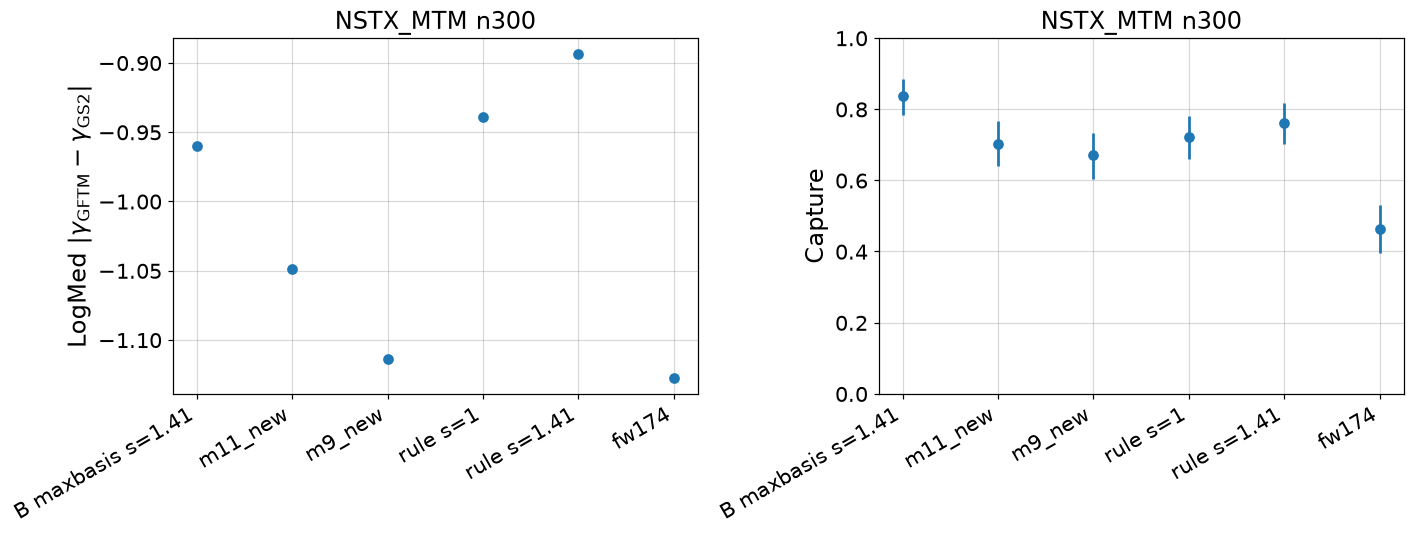

In [6]:
plot_dir = ROOT / "Plots" / analysis_name
plot_dir.mkdir(parents=True, exist_ok=True)
arms = draws["n300"][1]
table_n300 = table_mtm["n300"]
positions = np.arange(len(arms))
fig1, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(positions, [np.log10(table_n300[arm]["medae"]) for arm in arms], "o")
axes[0].set_ylabel(r"LogMed $|\gamma_{\rm GFTM}-\gamma_{\rm GS2}|$", fontsize=16)
capture = np.array([table_n300[arm]["capture"] for arm in arms])
axes[1].errorbar(positions, capture, yerr=np.array([np.abs(table_n300[arm]["cap_ci"] - table_n300[arm]["capture"]) for arm in arms]).T, ls="", marker="o")
axes[1].set_ylabel("Capture", fontsize=16)
axes[1].set_ylim(0, 1)
for axis in axes:
    axis.set_xticks(positions, arms, rotation=30, ha="right", fontsize=14)
    axis.set_title("NSTX_MTM n300", fontsize=16)
fig1.tight_layout()
plt.show()


## Save

In [7]:
fig1.savefig(plot_dir / "fig1_arms_mtm_only_n300.png")


## Interpretation

_To be written after the executed run._